<a href="https://colab.research.google.com/github/simsaran/manufacturing-process-intelligence/blob/main/notebooks/data_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Manufacturing Process Intelligence Platform
# Data Generator for Food Packaging Plant Simulation
# DMAIC Continuous Improvement Project
# Author: Shivansh

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Set random seed for reproducibility
np.random.seed(42)

# Configuration
NUM_DAYS = 90
SHIFTS = ['Day', 'Afternoon', 'Night']
LINES = ['Line A', 'Line B', 'Line C']
DEFECT_TYPES = ['Seal Failure', 'Underfill', 'Label Misalign',
                'Contamination', 'Torn Package', 'Wrong Date Code']

print("✅ Setup complete — generating 90 days × 3 shifts × 3 lines = 810 records")

✅ Setup complete — generating 90 days × 3 shifts × 3 lines = 810 records


In [ ]:
# Generate realistic production data with intentional process issues
records = []
start_date = datetime(2025, 1, 6)  # Start on a Monday

for day in range(NUM_DAYS):
    current_date = start_date + timedelta(days=day)
    day_of_week = current_date.strftime('%A')

    for shift in SHIFTS:
        for line in LINES:
            is_night = shift == 'Night'
            is_line_c = line == 'Line C'
            is_monday = day_of_week == 'Monday'  # Monday startup issues

            # ---- PROCESS VARIABLES (with intentional variation) ----

            # Seal temperature: Line C has drift issues, night shift less stable
            base_temp = 185
            temp_std = 6 if is_night else (4 if is_line_c else 2.5)
            seal_temp = np.random.normal(base_temp, temp_std)

            # Fill weight: target 500g, Line C has calibration issues
            base_fill = 500
            fill_std = 8 if is_line_c else 3
            fill_weight = np.random.normal(base_fill, fill_std)

            # Seal strength: night shift lower due to temperature drift
            base_seal = 45
            seal_std = 4.5 if is_night else 2
            seal_strength = np.random.normal(base_seal, seal_std)

            # Line speed: Line C inconsistent
            base_speed = 120
            speed_std = 12 if is_line_c else 5
            line_speed = np.random.normal(base_speed, speed_std)

            # Humidity (environmental factor)
            humidity = np.random.normal(55, 8)

            # ---- PRODUCTION OUTPUT ----
            units_produced = int(np.random.normal(2400, 200))

            # Defect probability (higher for night shift, Line C, high temp)
            defect_prob = 0.025  # baseline 2.5%
            if is_night: defect_prob += 0.03
            if is_line_c: defect_prob += 0.025
            if seal_temp > 192: defect_prob += 0.04
            if seal_temp < 178: defect_prob += 0.03
            if is_monday: defect_prob += 0.01  # Monday startup
            if humidity > 65: defect_prob += 0.015

            total_defects = int(units_produced * defect_prob)

            # Distribute defects across types (weighted)
            weights = [0.32, 0.24, 0.18, 0.12, 0.08, 0.06]
            defect_counts = np.random.multinomial(total_defects, weights)

            # Downtime (minutes per shift)
            downtime_base = 35 if is_line_c else 12
            downtime_min = max(0, int(np.random.normal(downtime_base, 10)))
            if is_monday: downtime_min += int(np.random.normal(8, 3))

            # ---- OEE CALCULATION ----
            planned_minutes = 480  # 8-hour shift
            availability = min(1.0, (planned_minutes - downtime_min) / planned_minutes)
            performance = min(1.0, line_speed / 130)  # 130 is ideal speed
            quality = min(1.0, (units_produced - total_defects) / units_produced)
            oee = availability * performance * quality

            # ---- COST CALCULATIONS ----
            cost_per_defect = {'Seal Failure': 4.50, 'Underfill': 3.20,
                             'Label Misalign': 1.80, 'Contamination': 8.00,
                             'Torn Package': 2.50, 'Wrong Date Code': 1.20}
            copq = sum(defect_counts[i] * list(cost_per_defect.values())[i]
                      for i in range(len(DEFECT_TYPES)))

            record = {
                'Date': current_date.strftime('%Y-%m-%d'),
                'Day_of_Week': day_of_week,
                'Shift': shift,
                'Line': line,
                'Seal_Temperature_C': round(seal_temp, 1),
                'Fill_Weight_g': round(fill_weight, 1),
                'Seal_Strength_N': round(seal_strength, 1),
                'Line_Speed_upm': round(line_speed, 1),
                'Humidity_pct': round(humidity, 1),
                'Units_Produced': units_produced,
                'Total_Defects': total_defects,
                'Defect_Rate_pct': round((total_defects / units_produced) * 100, 2),
                'Downtime_min': downtime_min,
                'Availability': round(availability, 3),
                'Performance': round(performance, 3),
                'Quality': round(quality, 3),
                'OEE': round(oee, 3),
                'COPQ_dollars': round(copq, 2),
            }

            # Add individual defect counts
            for i, dt in enumerate(DEFECT_TYPES):
                record[f'Defect_{dt.replace(" ", "_")}'] = defect_counts[i]

            records.append(record)

df = pd.DataFrame(records)
print(f"✅ Generated {len(df)} production records")
print(f"\n📊 Dataset Shape: {df.shape}")
print(f"\n📋 Columns: {list(df.columns)}")
df.head(10)

✅ Generated 810 production records

📊 Dataset Shape: (810, 24)

📋 Columns: ['Date', 'Day_of_Week', 'Shift', 'Line', 'Seal_Temperature_C', 'Fill_Weight_g', 'Seal_Strength_N', 'Line_Speed_upm', 'Humidity_pct', 'Units_Produced', 'Total_Defects', 'Defect_Rate_pct', 'Downtime_min', 'Availability', 'Performance', 'Quality', 'OEE', 'COPQ_dollars', 'Defect_Seal_Failure', 'Defect_Underfill', 'Defect_Label_Misalign', 'Defect_Contamination', 'Defect_Torn_Package', 'Defect_Wrong_Date_Code']


,Date,Day_of_Week,Shift,Line,Seal_Temperature_C,Fill_Weight_g,Seal_Strength_N,Line_Speed_upm,Humidity_pct,Units_Produced,...,Performance,Quality,OEE,COPQ_dollars,Defect_Seal_Failure,Defect_Underfill,Defect_Label_Misalign,Defect_Contamination,Defect_Torn_Package,Defect_Wrong_Date_Code
0,2025-01-06,Monday,Day,Line A,186.2,499.6,46.3,127.6,53.1,2353,...,0.982,0.965,0.924,311.9,20,26,15,11,9,1
1,2025-01-06,Monday,Day,Line B,183.6,497.2,39.8,124.8,61.5,2095,...,0.960,0.965,0.897,268.5,19,17,14,10,6,7
2,2025-01-06,Monday,Day,Line C,182.8,500.9,42.7,124.5,50.2,2341,...,0.958,0.940,0.764,542.5,43,28,26,21,14,8
3,2025-01-06,Monday,Afternoon,Line A,185.5,502.6,43.0,112.1,61.2,2292,...,0.862,0.965,0.808,283.0,24,18,16,8,6,8
4,2025-01-06,Monday,Afternoon,Line B,187.6,502.8,43.3,118.5,57.7,2595,...,0.911,0.965,0.828,333.3,27,17,17,12,8,9
5,2025-01-06,Monday,Afternoon,Line C,180.8,499.4,46.9,129.5,67.0,2467,...,0.997,0.925,0.822,682.4,50,57,34,21,14,9
6,2025-01-06,Monday,Night,Line A,181.8,495.5,41.4,123.7,53.3,2314,...,0.952,0.935,0.857,572.0,43,30,28,23,13,13
7,2025-01-06,Monday,Night,Line B,183.5,498.9,50.7,118.5,33.8,2469,...,0.912,0.935,0.815,612.7,55,36,26,20,12,11
8,2025-01-06,Monday,Night,Line C,173.5,499.8,45.3,149.6,53.5,2460,...,1.000,0.880,0.766,1073.7,91,69,57,31,28,19
9,2025-01-07,Tuesday,Day,Line A,185.0,498.9,46.3,113.9,59.3,2217,...,0.876,0.975,0.819,210.3,17,18,6,6,6,2


In [ ]:
# Key metrics summary — these feed into your project narrative
print("=" * 60)
print("📊 BASELINE PERFORMANCE METRICS (DEFINE PHASE)")
print("=" * 60)

print(f"\n🏭 Overall OEE: {df['OEE'].mean():.1%}")
print(f"   → Day Shift OEE: {df[df['Shift']=='Day']['OEE'].mean():.1%}")
print(f"   → Night Shift OEE: {df[df['Shift']=='Night']['OEE'].mean():.1%}")
print(f"   → Gap: {(df[df['Shift']=='Day']['OEE'].mean() - df[df['Shift']=='Night']['OEE'].mean()):.1%}")

print(f"\n❌ Overall Defect Rate: {df['Defect_Rate_pct'].mean():.2f}%")
print(f"   → Line A: {df[df['Line']=='Line A']['Defect_Rate_pct'].mean():.2f}%")
print(f"   → Line B: {df[df['Line']=='Line B']['Defect_Rate_pct'].mean():.2f}%")
print(f"   → Line C: {df[df['Line']=='Line C']['Defect_Rate_pct'].mean():.2f}%")

print(f"\n⏱️  Avg Downtime: {df['Downtime_min'].mean():.0f} min/shift")
print(f"   → Line C Avg: {df[df['Line']=='Line C']['Downtime_min'].mean():.0f} min/shift")

print(f"\n💰 Total COPQ (90 days): ${df['COPQ_dollars'].sum():,.0f}")
print(f"   → Annualized: ${df['COPQ_dollars'].sum() * (365/90):,.0f}")

# Defect Pareto
print(f"\n📊 DEFECT PARETO:")
defect_cols = [c for c in df.columns if c.startswith('Defect_') and c != 'Defect_Rate_pct']
defect_totals = df[defect_cols].sum().sort_values(ascending=False)
total_defects = defect_totals.sum()
cumulative = 0
for defect, count in defect_totals.items():
    cumulative += count
    name = defect.replace('Defect_', '').replace('_', ' ')
    print(f"   {name}: {count} ({count/total_defects:.0%}) — Cumulative: {cumulative/total_defects:.0%}")

📊 BASELINE PERFORMANCE METRICS (DEFINE PHASE)

🏭 Overall OEE: 83.3%
   → Day Shift OEE: 84.5%
   → Night Shift OEE: 81.3%
   → Gap: 3.2%

❌ Overall Defect Rate: 4.96%
   → Line A: 4.01%
   → Line B: 4.12%
   → Line C: 6.75%

⏱️  Avg Downtime: 21 min/shift
   → Line C Avg: 36 min/shift

💰 Total COPQ (90 days): $361,297
   → Annualized: $1,465,260

📊 DEFECT PARETO:
   Seal Failure: 30751 (32%) — Cumulative: 32%
   Underfill: 23110 (24%) — Cumulative: 56%
   Label Misalign: 17022 (18%) — Cumulative: 74%
   Contamination: 11490 (12%) — Cumulative: 86%
   Torn Package: 7752 (8%) — Cumulative: 94%
   Wrong Date Code: 5855 (6%) — Cumulative: 100%


⚠️  1 out of 162 subgroups are out of control


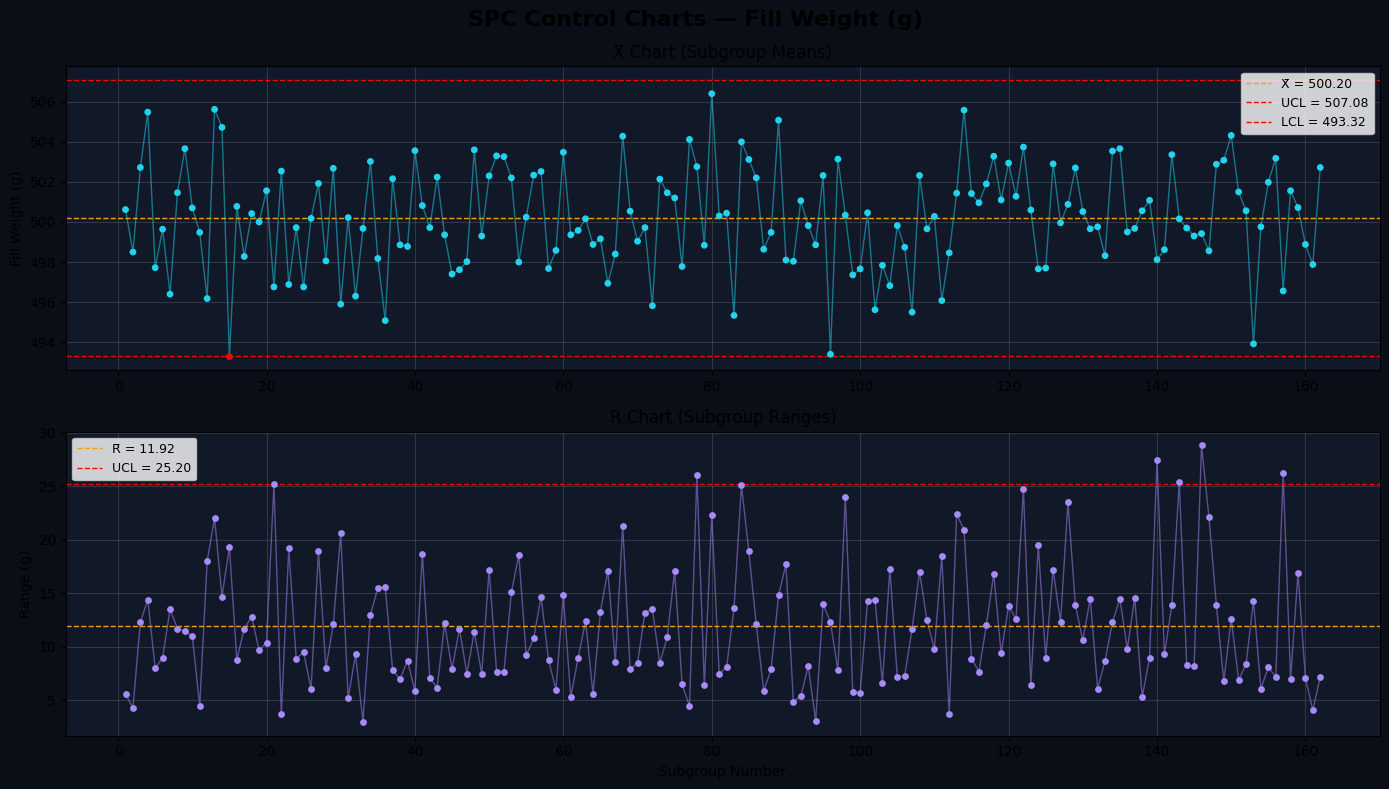

In [ ]:
# STATISTICAL PROCESS CONTROL — X-bar and R Charts
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('SPC Control Charts — Fill Weight (g)', fontsize=16, fontweight='bold')

# Calculate subgroup statistics (subgroup size = 5)
fill_values = df['Fill_Weight_g'].values
subgroup_size = 5
n_groups = len(fill_values) // subgroup_size

means = []
ranges = []
for i in range(n_groups):
    subgroup = fill_values[i*subgroup_size : (i+1)*subgroup_size]
    means.append(np.mean(subgroup))
    ranges.append(np.max(subgroup) - np.min(subgroup))

x_bar = np.mean(means)
r_bar = np.mean(ranges)

# Control chart constants for n=5
A2, D3, D4 = 0.577, 0, 2.114

ucl_x = x_bar + A2 * r_bar
lcl_x = x_bar - A2 * r_bar
ucl_r = D4 * r_bar
lcl_r = D3 * r_bar

# X-bar chart
ax1 = axes[0]
x_indices = range(1, n_groups + 1)
colors_pts = ['red' if m > ucl_x or m < lcl_x else '#22d3ee' for m in means]
ax1.scatter(x_indices, means, c=colors_pts, s=15, zorder=3)
ax1.plot(x_indices, means, color='#22d3ee', alpha=0.5, linewidth=1)
ax1.axhline(y=x_bar, color='#f59e0b', linestyle='--', linewidth=1, label=f'X̄ = {x_bar:.2f}')
ax1.axhline(y=ucl_x, color='red', linestyle='--', linewidth=1, label=f'UCL = {ucl_x:.2f}')
ax1.axhline(y=lcl_x, color='red', linestyle='--', linewidth=1, label=f'LCL = {lcl_x:.2f}')
ax1.set_title('X̄ Chart (Subgroup Means)', fontsize=12)
ax1.set_ylabel('Fill Weight (g)')
ax1.legend(fontsize=9)
ax1.set_facecolor('#111827')
ax1.grid(alpha=0.2)

# R chart
ax2 = axes[1]
ax2.scatter(x_indices, ranges, c='#a78bfa', s=15, zorder=3)
ax2.plot(x_indices, ranges, color='#a78bfa', alpha=0.5, linewidth=1)
ax2.axhline(y=r_bar, color='#f59e0b', linestyle='--', linewidth=1, label=f'R̄ = {r_bar:.2f}')
ax2.axhline(y=ucl_r, color='red', linestyle='--', linewidth=1, label=f'UCL = {ucl_r:.2f}')
ax2.set_title('R Chart (Subgroup Ranges)', fontsize=12)
ax2.set_ylabel('Range (g)')
ax2.set_xlabel('Subgroup Number')
ax2.legend(fontsize=9)
ax2.set_facecolor('#111827')
ax2.grid(alpha=0.2)

out_of_control = sum(1 for m in means if m > ucl_x or m < lcl_x)
print(f"⚠️  {out_of_control} out of {n_groups} subgroups are out of control")

fig.patch.set_facecolor('#0a0e17')
plt.tight_layout()
plt.savefig('spc_control_charts.png', dpi=150, bbox_inches='tight', facecolor='#0a0e17')
plt.show()

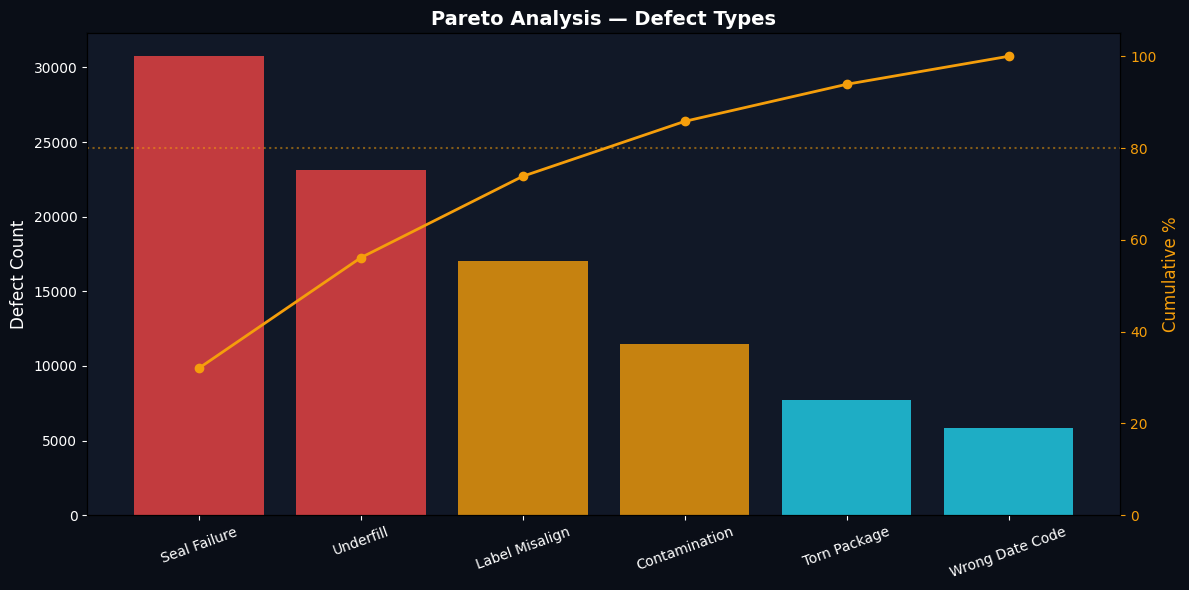

✅ Top 2 defects account for 56% of all defects (80/20 rule)


In [ ]:
# PARETO ANALYSIS
fig, ax1 = plt.subplots(figsize=(12, 6))

defect_cols = [c for c in df.columns if c.startswith('Defect_') and c != 'Defect_Rate_pct']
defect_sums = df[defect_cols].sum().sort_values(ascending=False)
defect_names = [c.replace('Defect_', '').replace('_', ' ') for c in defect_sums.index]
values = defect_sums.values

cumulative = np.cumsum(values) / values.sum() * 100

bar_colors = ['#ef4444', '#ef4444', '#f59e0b', '#f59e0b', '#22d3ee', '#22d3ee']
ax1.bar(defect_names, values, color=bar_colors, alpha=0.8, edgecolor='none')
ax1.set_ylabel('Defect Count', color='white', fontsize=12)
ax1.set_xlabel('')
ax1.tick_params(axis='y', colors='white')
ax1.tick_params(axis='x', colors='white', rotation=20)

ax2 = ax1.twinx()
ax2.plot(defect_names, cumulative, color='#f59e0b', marker='o', linewidth=2, markersize=6)
ax2.axhline(y=80, color='#f59e0b', linestyle=':', alpha=0.5)
ax2.set_ylabel('Cumulative %', color='#f59e0b', fontsize=12)
ax2.tick_params(axis='y', colors='#f59e0b')
ax2.set_ylim(0, 105)

ax1.set_facecolor('#111827')
fig.patch.set_facecolor('#0a0e17')
plt.title('Pareto Analysis — Defect Types', fontsize=14, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('pareto_chart.png', dpi=150, bbox_inches='tight', facecolor='#0a0e17')
plt.show()

print(f"✅ Top 2 defects account for {cumulative[1]:.0f}% of all defects (80/20 rule)")

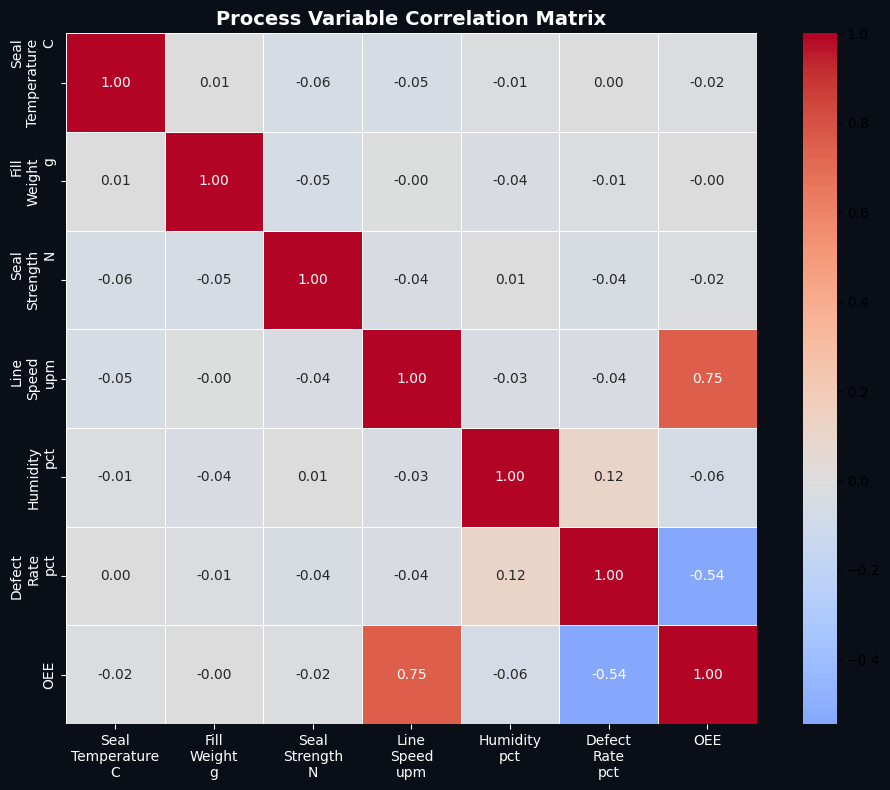

In [ ]:
# CORRELATION ANALYSIS
process_vars = ['Seal_Temperature_C', 'Fill_Weight_g', 'Seal_Strength_N',
                'Line_Speed_upm', 'Humidity_pct', 'Defect_Rate_pct', 'OEE']

corr_matrix = df[process_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax,
            xticklabels=[v.replace('_', '\n') for v in process_vars],
            yticklabels=[v.replace('_', '\n') for v in process_vars])

plt.title('Process Variable Correlation Matrix', fontsize=14, fontweight='bold', color='white')
ax.set_facecolor('#111827')
fig.patch.set_facecolor('#0a0e17')
ax.tick_params(colors='white')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0a0e17')
plt.show()

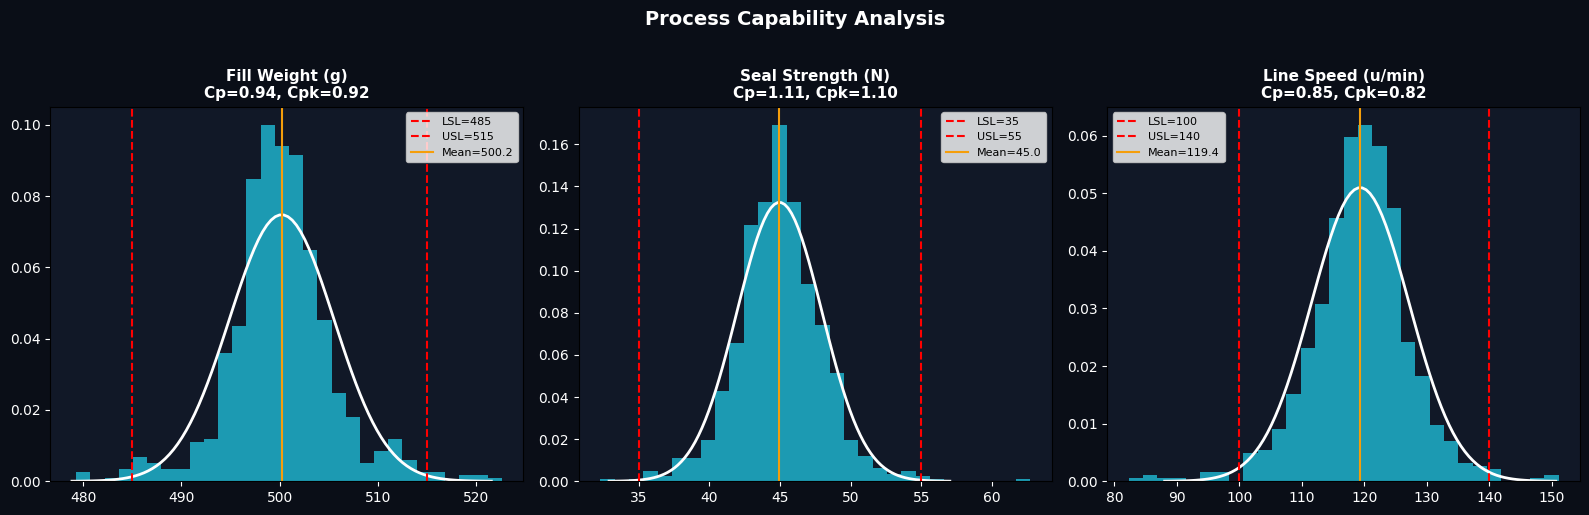

In [ ]:
# PROCESS CAPABILITY ANALYSIS
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

capabilities = [
    ('Fill_Weight_g', 485, 515, 500, 'Fill Weight (g)'),
    ('Seal_Strength_N', 35, 55, 45, 'Seal Strength (N)'),
    ('Line_Speed_upm', 100, 140, 120, 'Line Speed (u/min)')
]

for ax, (col, lsl, usl, target, title) in zip(axes, capabilities):
    data = df[col]
    mean = data.mean()
    std = data.std()

    # Calculate Cp and Cpk
    cp = (usl - lsl) / (6 * std)
    cpk = min((usl - mean) / (3 * std), (mean - lsl) / (3 * std))

    # Histogram with normal curve
    ax.hist(data, bins=30, density=True, alpha=0.7, color='#22d3ee', edgecolor='none')

    x_range = np.linspace(mean - 4*std, mean + 4*std, 100)
    normal_curve = (1/(std * np.sqrt(2*np.pi))) * np.exp(-0.5*((x_range-mean)/std)**2)
    ax.plot(x_range, normal_curve, color='white', linewidth=2)

    ax.axvline(x=lsl, color='red', linestyle='--', linewidth=1.5, label=f'LSL={lsl}')
    ax.axvline(x=usl, color='red', linestyle='--', linewidth=1.5, label=f'USL={usl}')
    ax.axvline(x=mean, color='#f59e0b', linestyle='-', linewidth=1.5, label=f'Mean={mean:.1f}')

    ax.set_title(f'{title}\nCp={cp:.2f}, Cpk={cpk:.2f}', fontsize=11, color='white', fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_facecolor('#111827')
    ax.tick_params(colors='white')

fig.patch.set_facecolor('#0a0e17')
plt.suptitle('Process Capability Analysis', fontsize=14, color='white', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('process_capability.png', dpi=150, bbox_inches='tight', facecolor='#0a0e17')
plt.show()

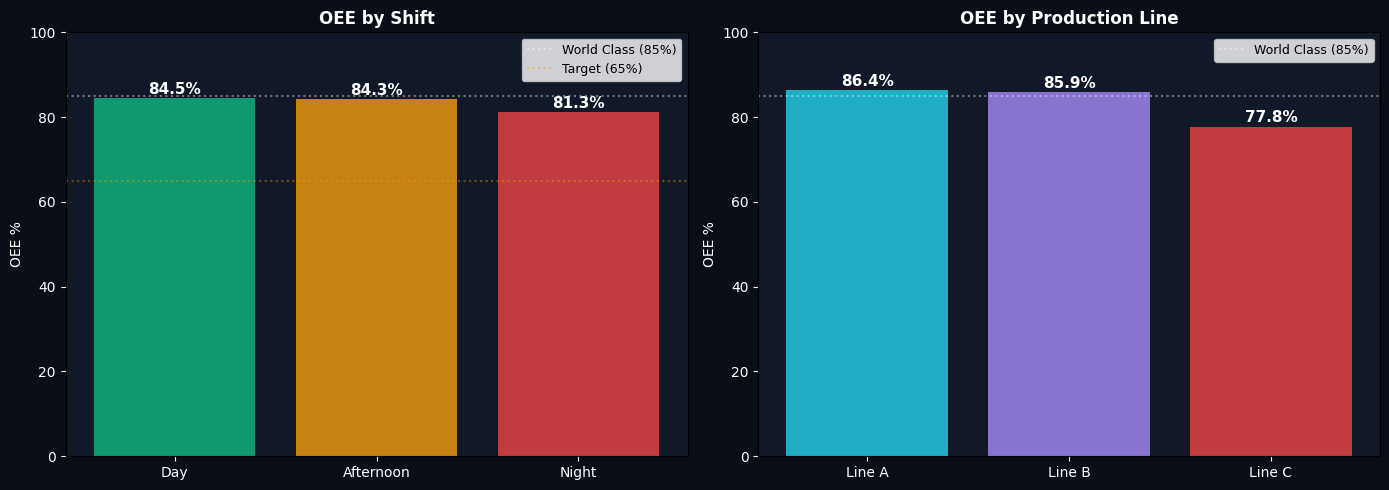

In [ ]:
# OEE BREAKDOWN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OEE by Shift
shift_oee = df.groupby('Shift')['OEE'].mean().reindex(['Day', 'Afternoon', 'Night'])
colors_shift = ['#10b981', '#f59e0b', '#ef4444']
axes[0].bar(shift_oee.index, shift_oee.values * 100, color=colors_shift, alpha=0.8, edgecolor='none')
axes[0].axhline(y=85, color='white', linestyle=':', alpha=0.4, label='World Class (85%)')
axes[0].axhline(y=65, color='#f59e0b', linestyle=':', alpha=0.4, label='Target (65%)')
axes[0].set_title('OEE by Shift', color='white', fontsize=12, fontweight='bold')
axes[0].set_ylabel('OEE %', color='white')
axes[0].legend(fontsize=9)
axes[0].set_facecolor('#111827')
axes[0].tick_params(colors='white')
axes[0].set_ylim(0, 100)

# Add value labels
for i, v in enumerate(shift_oee.values):
    axes[0].text(i, v*100 + 1, f'{v*100:.1f}%', ha='center', color='white', fontsize=11, fontweight='bold')

# OEE by Line
line_oee = df.groupby('Line')['OEE'].mean()
colors_line = ['#22d3ee', '#a78bfa', '#ef4444']
axes[1].bar(line_oee.index, line_oee.values * 100, color=colors_line, alpha=0.8, edgecolor='none')
axes[1].axhline(y=85, color='white', linestyle=':', alpha=0.4, label='World Class (85%)')
axes[1].set_title('OEE by Production Line', color='white', fontsize=12, fontweight='bold')
axes[1].set_ylabel('OEE %', color='white')
axes[1].legend(fontsize=9)
axes[1].set_facecolor('#111827')
axes[1].tick_params(colors='white')
axes[1].set_ylim(0, 100)

for i, v in enumerate(line_oee.values):
    axes[1].text(i, v*100 + 1, f'{v*100:.1f}%', ha='center', color='white', fontsize=11, fontweight='bold')

fig.patch.set_facecolor('#0a0e17')
plt.tight_layout()
plt.savefig('oee_breakdown.png', dpi=150, bbox_inches='tight', facecolor='#0a0e17')
plt.show()

In [ ]:
# EXPORT DATASET FOR POWER BI AND GITHUB

# Main dataset
df.to_csv('production_data.csv', index=False)
print(f"✅ Exported production_data.csv ({len(df)} rows × {len(df.columns)} columns)")

# Summary by day (for Power BI trend charts)
daily = df.groupby('Date').agg({
    'OEE': 'mean',
    'Defect_Rate_pct': 'mean',
    'Downtime_min': 'mean',
    'Units_Produced': 'sum',
    'Total_Defects': 'sum',
    'COPQ_dollars': 'sum'
}).round(3).reset_index()
daily.to_csv('daily_summary.csv', index=False)
print(f"✅ Exported daily_summary.csv ({len(daily)} rows)")

# Summary by shift+line (for Power BI breakdown)
breakdown = df.groupby(['Shift', 'Line']).agg({
    'OEE': 'mean',
    'Defect_Rate_pct': 'mean',
    'Downtime_min': 'mean',
    'Units_Produced': 'sum',
    'Total_Defects': 'sum',
    'COPQ_dollars': 'sum',
    'Availability': 'mean',
    'Performance': 'mean',
    'Quality': 'mean'
}).round(3).reset_index()
breakdown.to_csv('shift_line_breakdown.csv', index=False)
print(f"✅ Exported shift_line_breakdown.csv ({len(breakdown)} rows)")

# Download all files
from google.colab import files
files.download('production_data.csv')
files.download('daily_summary.csv')
files.download('shift_line_breakdown.csv')
print("\n📥 All 3 CSV files downloaded!")
print("→ Upload production_data.csv to your GitHub repo's /data/ folder")
print("→ Upload all 3 CSVs to Power BI for the dashboard")

✅ Exported production_data.csv (810 rows × 24 columns)
✅ Exported daily_summary.csv (90 rows)
✅ Exported shift_line_breakdown.csv (9 rows)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 All 3 CSV files downloaded!
→ Upload production_data.csv to your GitHub repo's /data/ folder
→ Upload all 3 CSVs to Power BI for the dashboard
